# Random-forest FOMC prediction visualizer

## tl;dr

This notebook visualizes **55 chronological random-forest holdout predictions** from October 30, 2019 through July 29, 2026. The predicted class matched **51 decisions (92.7%)**. The three highest impurity-based feature importances are `treasury_6m_minus_funds_pct`, `treasury_3m_minus_funds_pct`, `treasury_1y_minus_funds_pct`.

## Context & Methods

The notebook uses only the `random_forest_*` fields in `outputs/tree_model_predictions.csv`, merges meeting values from `data/clean/clean_panel.csv`, and reads random-forest importance from `outputs/tree_model_feature_importance.csv`.

### Key Assumptions

- The policy-rate line is the observed target midpoint after each meeting.
- Unemployment is the aligned value stored in the clean meeting panel.
- Markers indicate predicted classes, not predicted numeric rates.
- Feature importance is mean decrease in impurity, not a causal effect.
- The confusion matrix contains meeting counts, not percentages.

## Data

### 1. Load and validate inputs

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

workspace = Path.cwd().resolve()
contents = workspace / 'contents' if (workspace / 'contents').is_dir() else workspace
if str(contents) not in sys.path:
    sys.path.insert(0, str(contents))
from build_random_forest_visualizer import load_random_forest_visualizer_data

plot_data, feature_importance = load_random_forest_visualizer_data()
probability_columns = ['probability_cut', 'probability_hold', 'probability_hike']
assert plot_data.meeting_date.is_unique
assert np.allclose(plot_data[probability_columns].sum(axis=1), 1.0)
assert feature_importance.feature.is_unique
assert np.isclose(feature_importance.random_forest_importance.sum(), 1.0)
plot_data[['meeting_date', 'actual_decision', 'predicted_decision', 'policy_rate_after', 'unemployment']].head()

,meeting_date,actual_decision,predicted_decision,policy_rate_after,unemployment
0,2019-10-30,cut,cut,1.625,3.5
1,2019-12-11,hold,hold,1.625,3.6
2,2020-01-29,hold,hold,1.625,3.6
3,2020-03-02,hold,cut,1.625,3.5
4,2020-03-15,cut,cut,0.125,3.5


## Results

### 2. Interest-rate path and random-forest decisions

The line is the observed post-meeting target midpoint. Marker shape and color identify the random forest's predicted decision.

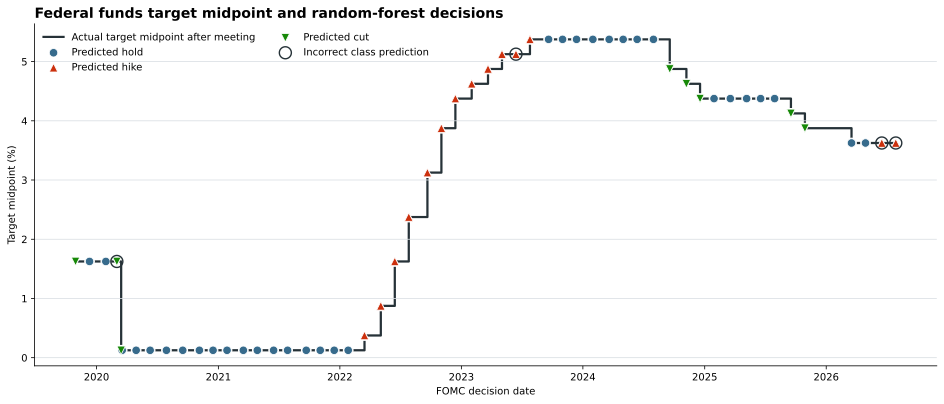

In [2]:
INK = '#263238'
BLUE = '#376B8C'
GOLD = '#D4AF37'
ORANGE = '#178908'
GREEN = '#178908'
RED = '#CC300D'
GRID = '#D9DEE3'
MUTED = '#73808C'
DECISION_STYLE = {
    'cut': {'color': GREEN, 'marker': 'v', 'label': 'Predicted cut'},
    'hold': {'color': BLUE, 'marker': 'o', 'label': 'Predicted hold'},
    'hike': {'color': RED, 'marker': '^', 'label': 'Predicted hike'},
}
# Draw holds first and cuts last. Closely spaced emergency meetings can
# otherwise let a later hold marker hide the marker for a large cut.
DECISION_PLOT_ORDER = ('hold', 'hike', 'cut')
incorrect = plot_data.actual_decision.ne(plot_data.predicted_decision)

fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)
ax.step(plot_data.meeting_date, plot_data.policy_rate_after, where='post', color=INK, linewidth=2.25, zorder=1, label='Actual target midpoint after meeting')
# A shared white halo separates every marker from vertical rate steps.
for decision in DECISION_PLOT_ORDER:
    style = DECISION_STYLE[decision]
    selected = plot_data.predicted_decision.eq(decision)
    ax.scatter(plot_data.loc[selected, 'meeting_date'], plot_data.loc[selected, 'policy_rate_after'], s=116, marker=style['marker'], color='white', edgecolor='white', linewidth=0, zorder=2)
for layer, decision in enumerate(DECISION_PLOT_ORDER, start=3):
    style = DECISION_STYLE[decision]
    selected = plot_data.predicted_decision.eq(decision)
    ax.scatter(plot_data.loc[selected, 'meeting_date'], plot_data.loc[selected, 'policy_rate_after'], s=72, marker=style['marker'], color=style['color'], edgecolor='white', linewidth=0.8, zorder=layer, label=style['label'])
ax.scatter(plot_data.loc[incorrect, 'meeting_date'], plot_data.loc[incorrect, 'policy_rate_after'], s=145, facecolors='none', edgecolors=INK, linewidth=1.4, zorder=7, label='Incorrect class prediction')
ax.set_title('Federal funds target midpoint and random-forest decisions', loc='left', fontsize=14, weight='bold')
ax.set_ylabel('Target midpoint (%)')
ax.set_xlabel('FOMC decision date')
ax.grid(axis='y', color=GRID, linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, ncols=2, loc='upper left')
plt.show()

### 3. Unemployment path and random-forest decisions

The solid line is aligned unemployment and the dashed line is the CBO natural-rate estimate.

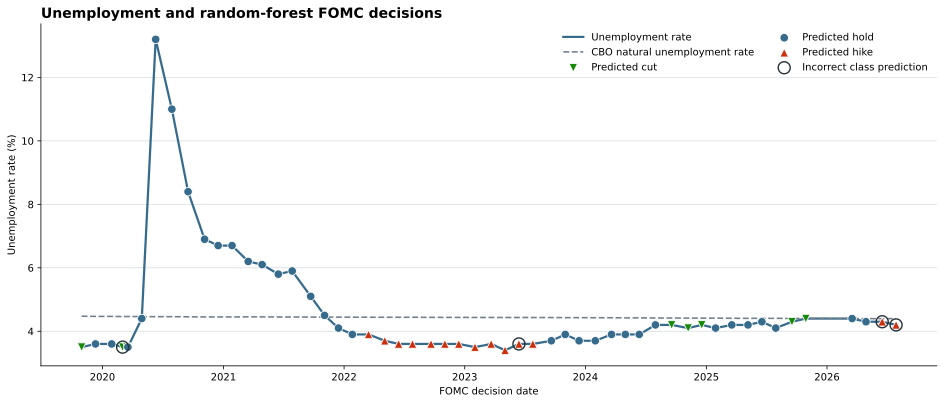

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)
ax.plot(plot_data.meeting_date, plot_data.unemployment, color=BLUE, linewidth=2.25, label='Unemployment rate')
ax.plot(plot_data.meeting_date, plot_data.natural_unemployment, color=MUTED, linewidth=1.6, linestyle='--', label='CBO natural unemployment rate')
for decision, style in DECISION_STYLE.items():
    selected = plot_data.predicted_decision.eq(decision)
    ax.scatter(plot_data.loc[selected, 'meeting_date'], plot_data.loc[selected, 'unemployment'], s=72, marker=style['marker'], color=style['color'], edgecolor='white', linewidth=0.8, zorder=3, label=style['label'])
ax.scatter(plot_data.loc[incorrect, 'meeting_date'], plot_data.loc[incorrect, 'unemployment'], s=145, facecolors='none', edgecolors=INK, linewidth=1.4, zorder=4, label='Incorrect class prediction')
ax.set_title('Unemployment and random-forest FOMC decisions', loc='left', fontsize=14, weight='bold')
ax.set_ylabel('Unemployment rate (%)')
ax.set_xlabel('FOMC decision date')
ax.grid(axis='y', color=GRID, linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, ncols=2, loc='upper right')
plt.show()

### 4. Random-forest confusion matrix

Rows are actual decisions and columns are random-forest predictions. Each square is the number of holdout meetings.

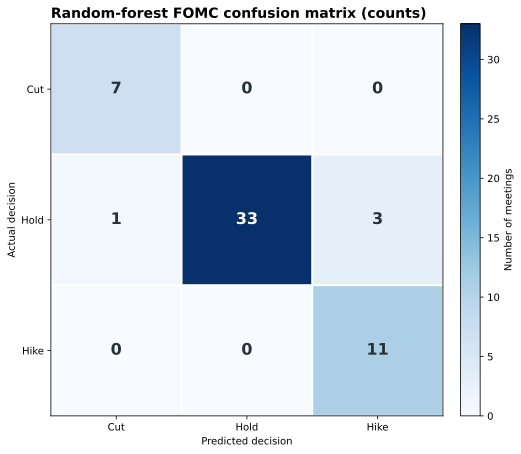

In [4]:
decision_order = ['cut', 'hold', 'hike']
confusion = pd.crosstab(plot_data.actual_decision, plot_data.predicted_decision).reindex(index=decision_order, columns=decision_order, fill_value=0)
matrix = confusion.to_numpy(dtype=int)
fig, ax = plt.subplots(figsize=(7.2, 6.2), constrained_layout=True)
image = ax.imshow(matrix, cmap='Blues', vmin=0, vmax=max(1, matrix.max()))
colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label('Number of meetings')
ax.set_xticks(range(3), [label.title() for label in decision_order])
ax.set_yticks(range(3), [label.title() for label in decision_order])
ax.set_xlabel('Predicted decision')
ax.set_ylabel('Actual decision')
ax.set_title('Random-forest FOMC confusion matrix (counts)', loc='left', fontsize=14, weight='bold')
threshold = matrix.max() / 2 if matrix.max() else 0
for row in range(3):
    for column in range(3):
        value = matrix[row, column]
        ax.text(column, row, str(value), ha='center', va='center', fontsize=16, weight='bold', color='white' if value > threshold else INK)
ax.set_xticks(np.arange(-0.5, 3, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 3, 1), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)
ax.set_aspect('equal')
plt.show()

### 5. Random-forest feature importance

The chart shows the top 15 features by mean decrease in impurity. The complete ranking remains available in the source CSV.

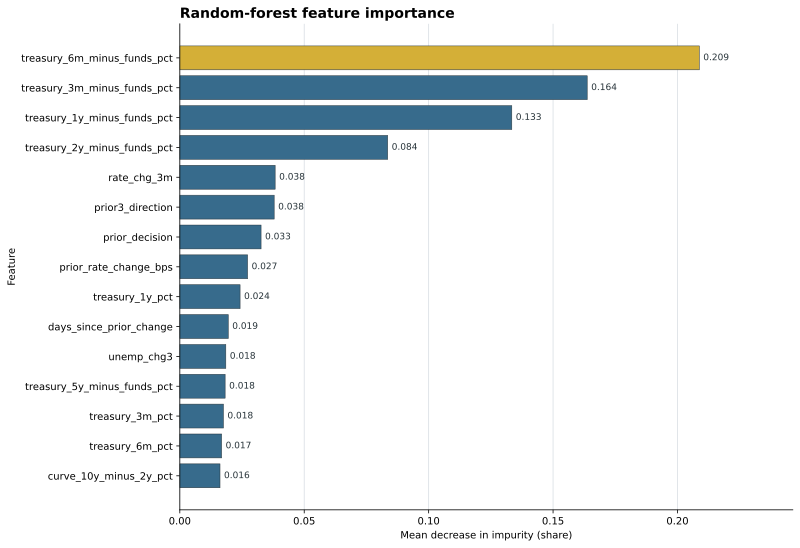

In [5]:
top_importance = feature_importance.head(15).sort_values('random_forest_importance', ascending=True)
bar_colors = [GOLD if feature == feature_importance.iloc[0].feature else BLUE for feature in top_importance.feature]
fig, ax = plt.subplots(figsize=(11, 7.5), constrained_layout=True)
bars = ax.barh(top_importance.feature, top_importance.random_forest_importance, color=bar_colors, edgecolor=INK, linewidth=0.5)
ax.bar_label(bars, fmt='%.3f', padding=4, color=INK, fontsize=9)
ax.set_title('Random-forest feature importance', loc='left', fontsize=14, weight='bold')
ax.set_xlabel('Mean decrease in impurity (share)')
ax.set_ylabel('Feature')
ax.set_xlim(0, max(top_importance.random_forest_importance) * 1.18)
ax.grid(axis='x', color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
plt.show()

### 6. Validate plotted results

In [6]:
assert confusion.shape == (3, 3)
assert int(confusion.to_numpy().sum()) == len(plot_data)
assert int(np.trace(confusion.to_numpy())) == int(plot_data.actual_decision.eq(plot_data.predicted_decision).sum())
assert len(top_importance) == min(15, len(feature_importance))
class_recall = pd.Series({decision: confusion.loc[decision, decision] / confusion.loc[decision].sum() for decision in decision_order}, name='recall')
display(pd.DataFrame({'actual_meetings': confusion.sum(axis=1), 'correct_predictions': pd.Series(np.diag(confusion), index=decision_order), 'recall': class_recall}))
feature_importance.head(10)

,actual_meetings,correct_predictions,recall
cut,7,7,1.000000
hold,37,33,0.891892
hike,11,11,1.000000


,feature,random_forest_importance,rank
0,treasury_6m_minus_funds_pct,0.208766,1
1,treasury_3m_minus_funds_pct,0.163720,2
2,treasury_1y_minus_funds_pct,0.133418,3
3,treasury_2y_minus_funds_pct,0.083544,4
4,rate_chg_3m,0.038317,5
5,prior3_direction,0.037924,6
6,prior_decision,0.032658,7
7,prior_rate_change_bps,0.027243,8
8,treasury_1y_pct,0.024221,9
9,days_since_prior_change,0.019466,10


## Takeaways

- The time-series charts show where the random forest's predicted decision agreed or disagreed with the observed decision.
- The confusion matrix gives exact cut, hold, and hike counts.
- Feature importance reports how often and how effectively a feature reduced impurity across the forest; correlated features can exchange importance.
- These are historical holdout results, not live forecasts or causal claims.